In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import matplotlib.pyplot as plt
import plotly.express as px
sns.set_theme(style="whitegrid")
from pathlib import Path
import plotly.express as px

def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace(",", "", regex=False), errors="coerce")

def save_png(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=200)
    plt.show()


In [2]:
uno_wait = pd.read_csv("uno_waitlist.csv")
uno_wait.head()

,state,abbr,region,organ,tot_pop,median_income,poverty_share,uninsured_share,waitlist_all_time,waitlist_per_100k,waitlist_1y_plus,long_wait_share_1y_plus,est_mean_wait_days,pct_wait_1y_plus,pct_wait_5y_plus,mortality_crude_rate
0,All _Center_States,abb,reg,Kidney,NaN,NaN,NaN,NaN,94408,NaN,61573,0.652201,745.015263,0.612601,0.094668,NaN
1,Alabama,AL,South,Kidney,5157699.0,63999.0,0.904855,0.124140,995,19.291548,567,0.569849,745.015263,0.612601,0.094668,1204.1
2,Arizona,AZ,West,Kidney,7582384.0,79964.0,0.827271,0.138563,2081,27.445194,1056,0.507448,745.015263,0.612601,0.094668,952.2
3,Arkansas,AR,South,Kidney,3088354.0,60773.0,0.919518,0.147631,338,10.944341,154,0.455621,745.015263,0.612601,0.094668,1188.3
4,California,CA,West,Kidney,39431263.0,99122.0,0.928029,0.158955,17864,45.304154,13538,0.757837,745.015263,0.612601,0.094668,758.9


In [3]:
uno_trans = pd.read_csv("uno_transplant.csv")
uno_trans.head()

,Year,All Recipient Ages,< 1 Year,1-5 Years,6-10 Years,11-17 Years,18-34 Years,35-49 Years,50-64 Years,65+ years,...,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin
0,To Date,1068934,10171,18090,10810,27276,139441,282734,418755,161642,...,"12,038","1,459","28,188","88,463","13,027",826,"26,549","21,100","2,249","26,039"
1,2026,4002,13,33,27,47,349,884,1580,1069,...,76,3,97,381,57,0,111,73,5,78
2,2025,49065,243,494,302,835,4360,10800,19487,12544,...,950,50,"1,517","4,774",882,2,"1,369",922,103,962
3,2024,48150,254,521,311,887,4320,10550,19295,12012,...,850,70,"1,566","4,425",810,16,"1,429",900,102,879
4,2023,46634,253,510,344,809,4427,10280,18907,11104,...,673,51,"1,447","4,230",714,12,"1,340",877,147,830


In [4]:
cand_reg_waitlist = pd.read_csv("Cand+reg_Organ_by_Waiting._Time.csv")
cand_reg_waitlist.head()

,All _Organs,Type,Category_type,All Time,< 30 Days,30 to < 90 Days,90 Days to < 6 Months,6 Months to < 1 Year,1 Year to < 2 Years,2 Years to < 3 Years,3 Years to < 5 Years,5 or More Years
0,All Organs,All _Races,Registrations,"120,648","6,033","8,741","13,551","21,536","26,703","16,851","16,546","10,687"
1,NaN,NaN,Candidates,"108,691","5,825","8,378","12,913","20,424","25,234","16,152","15,935","10,384"
2,NaN,White,Registrations,"45,386","2,580","3,594","5,424","8,399","9,920","6,090","5,781","3,598"
3,NaN,White,Candidates,"41,193","2,490","3,457","5,148","7,946","9,379","5,815","5,552","3,488"
4,NaN,Black,Registrations,"33,298","1,566","2,277","3,709","5,924","7,627","4,854","4,633","2,708"


In [5]:
cand_reg_waitlist.describe()

,All _Organs,Type,Category_type,All Time,< 30 Days,30 to < 90 Days,90 Days to < 6 Months,6 Months to < 1 Year,1 Year to < 2 Years,2 Years to < 3 Years,3 Years to < 5 Years,5 or More Years
count,9,152,153,153,153,153,153,153,153,153,153,153
unique,9,56,50,131,104,90,81,99,95,72,52,59
top,All Organs,White,Registrations,159,1,0,0,0,0,0,0,0
freq,1,18,53,4,12,14,24,13,16,23,56,57


In [6]:
census = pd.read_csv("census_cleaned.csv")
census.head()

,geo_id,state_name,Abbr,fip_county,state_fip,tot_pop,male_est,female_est,under_18_years,16_years_and_over,...,EDUCATIONAL _ATTAINMENT,median_income,poverty_rate,uninsured_rate,Insured,geo_fips5_extracted,geo_state_fips_2_extracted,state_fips_2,poverty_col_share_of_totpop,uninsured_col_share_of_totpop
0,0400000US01001,Alabama,AL,1,1001,5157699,2490551,2667148,1132203,4160138,...,685395,63999,4666970,640276,4347556,1001,1,1,0.904855,0.124140
1,0400000US01002,Alaska,AK,2,1002,740133,390301,349832,174198,586083,...,122920,92788,696822,134276,617791,1002,1,2,0.941482,0.181421
2,0400000US01004,Arizona,AZ,4,1004,7582384,3782883,3799501,1585751,6193806,...,1066295,79964,6272686,1050638,6143407,1004,1,4,0.827271,0.138563
3,0400000US01005,Arkansas,AR,5,1005,3088354,1517526,1570828,698141,2477205,...,370576,60773,2839798,455936,2702497,1005,1,5,0.919518,0.147631
4,0400000US01006,California,CA,6,1006,39431263,19675103,19756160,8411338,32089744,...,7206310,99122,36593372,6267799,35919912,1006,1,6,0.928029,0.158955


In [7]:
cdc_mort = pd.read_csv("CDC_MORTALITY_cleaned_joined_long.csv")
cdc_mort.head()

,breakdown,category,category_code,Deaths,Population,Crude Rate,Lower CI,Upper CI,Year,is_total
0,Age Groups,< 1 year,1,"142,638.00","25,878,128.00",551.2,548.3,554.1,NaN,False
1,Age Groups,1-4 years,1 - 4.,"26,909.00","107,286,287.00",25.1,24.8,25.4,NaN,False
2,Age Groups,5-14 years,5 - 14.,"40,729.00","287,785,979.00",14.2,14.0,14.3,NaN,False
3,Age Groups,15-24 years,15-24.,"232,944.00","304,328,641.00",76.5,76.2,76.9,NaN,False
4,Age Groups,25-34 years,25-34.,"473,427.00","320,700,526.00",147.6,147.2,148.0,NaN,False


In [8]:

# ---------- Helpers (no hard-coding) ----------

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^a-z0-9_]", "", regex=True)
    )
    return df

def clean_number_series(s: pd.Series) -> pd.Series:
    """Turn '12,345' or ' 3.2% ' into numeric; non-parsable -> NaN."""
    if s.dtype != "O":
        return pd.to_numeric(s, errors="coerce")
    out = (
        s.astype(str)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan})
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
    )
    return pd.to_numeric(out, errors="coerce")

def find_col(df: pd.DataFrame, patterns: list[str], required=True) -> str | None:
    """Find first column matching any regex pattern (case-insensitive)."""
    cols = list(df.columns)
    for pat in patterns:
        rx = re.compile(pat, flags=re.I)
        matches = [c for c in cols if rx.search(c)]
        if matches:
            return matches[0]
    if required:
        raise KeyError(f"Could not find a column matching patterns: {patterns}. Available: {cols}")
    return None

def add_quantile_bins(df: pd.DataFrame, col: str, q: int = 4, label_prefix="Q") -> pd.DataFrame:
    """Create income/poverty/etc bins from the data distribution."""
    df = df.copy()
    # qcut can fail if too many ties; rank-based fallback
    try:
        df[f"{col}_bin"] = pd.qcut(df[col], q=q, duplicates="drop")
    except ValueError:
        df[f"{col}_bin"] = pd.qcut(df[col].rank(method="average"), q=q, duplicates="drop")
    return df

def plot_bar(df, x, y, title, rotate=90):
    ax = df.plot(kind="bar", x=x, y=y, legend=False)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    plt.xticks(rotation=rotate)
    plt.tight_layout()
    plt.show()

def plot_scatter(df, x, y, title):
    ax = df.plot(kind="scatter", x=x, y=y)
    ax.set_title(title)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    plt.tight_layout()
    plt.show()

Clean uno_waitlist

In [9]:
# 1) Inspect columns (helps confirm what exists)
print("Columns:", uno_wait.columns.tolist())

# 2) Find the key columns dynamically (no hard-coding)
organ_col  = find_col(uno_wait, [r"^organ$", r"organ"])
region_col = find_col(uno_wait, [r"^region$", r"region"])
# (Optional if you need it later)
state_col  = find_col(uno_wait, [r"^state$", r"state"], required=False)

print("organ_col :", organ_col)
print("region_col:", region_col)
print("state_col :", state_col)

wait_rate_col = find_col(uno_wait, [r"waitlist_per_100k"])
by_organ_region = (
    uno_wait.groupby([organ_col, region_col], as_index=False)[wait_rate_col]
    .mean()
    .sort_values([organ_col, wait_rate_col], ascending=[True, False])
)
display(by_organ_region.head(20))

Columns: ['state', 'abbr', 'region', 'organ', 'tot_pop', 'median_income', 'poverty_share', 'uninsured_share', 'waitlist_all_time', 'waitlist_per_100k', 'waitlist_1y_plus', 'long_wait_share_1y_plus', 'est_mean_wait_days', 'pct_wait_1y_plus', 'pct_wait_5y_plus', 'mortality_crude_rate']
organ_col : organ
region_col: region
state_col : state


,organ,region,waitlist_per_100k
2,Heart,South,1.358484
0,Heart,Midwest,1.196061
1,Heart,Northeast,0.805597
5,Heart,West,0.639772
3,Heart,Territory,0.187307
4,Heart,Unknown,NaN
8,Kidney,South,31.770210
7,Kidney,Northeast,30.332226
10,Kidney,West,23.916339
6,Kidney,Midwest,23.157624


Average waitlist per 100k by region (per organ)

Organs found: ['Heart', 'Kidney', 'Lung']


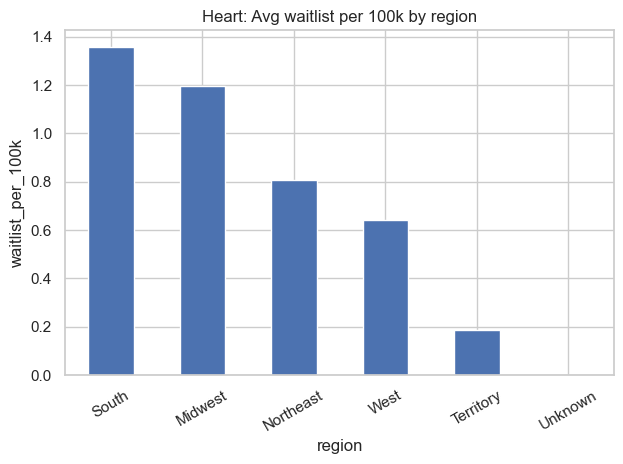

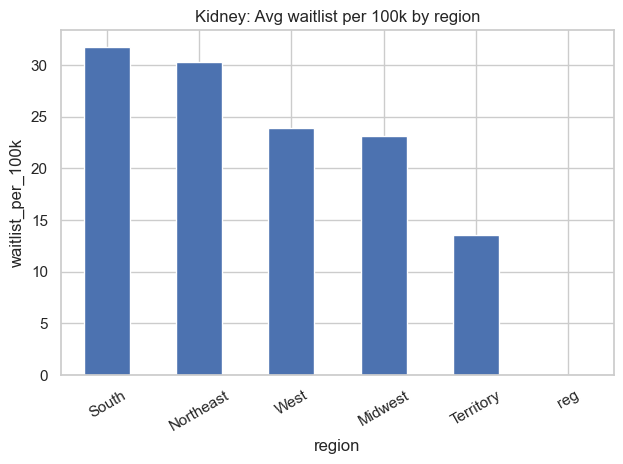

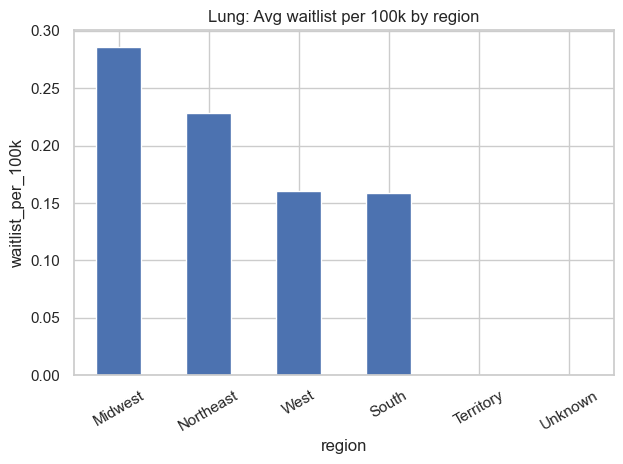

In [10]:
organs = sorted(uno_wait[organ_col].dropna().astype(str).unique())
print("Organs found:", organs)

for o in organs:
    tmp = by_organ_region[by_organ_region[organ_col] == o].copy()
    plot_bar(tmp, x=region_col, y=wait_rate_col, title=f"{o}: Avg waitlist per 100k by region", rotate=30)

Wait time disparities

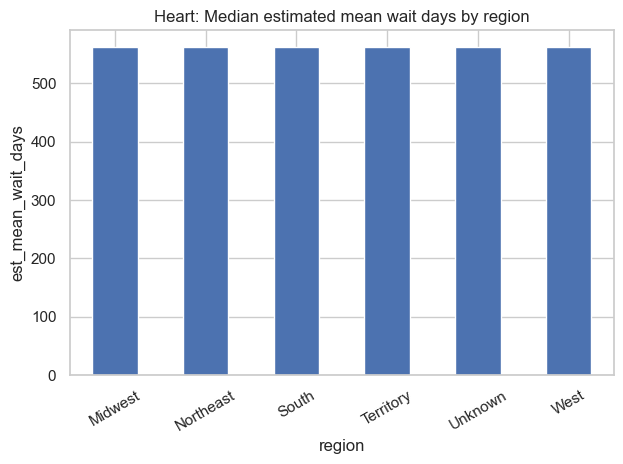

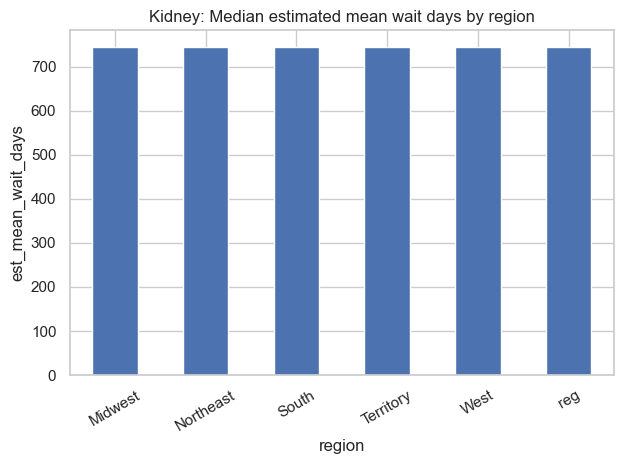

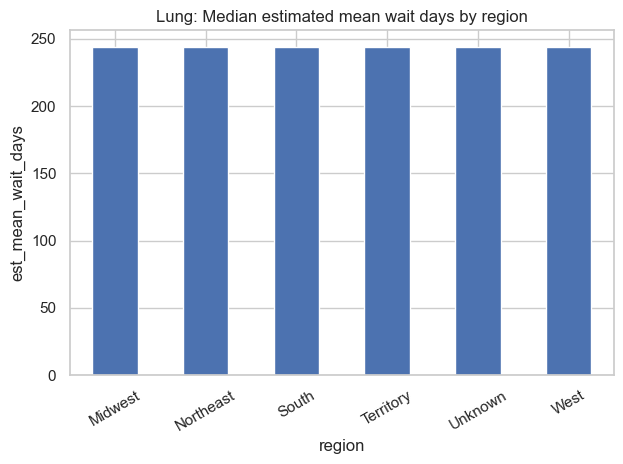

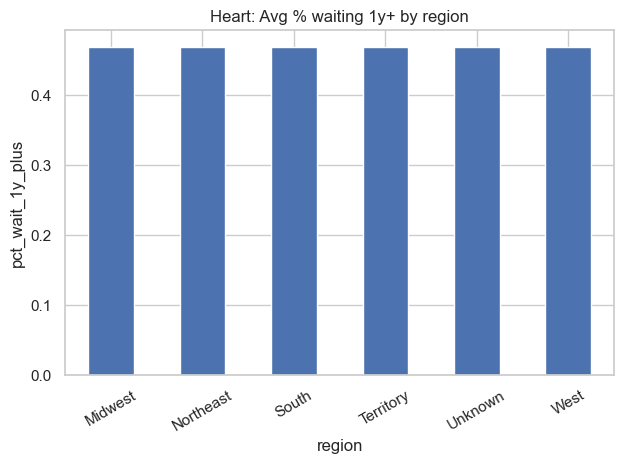

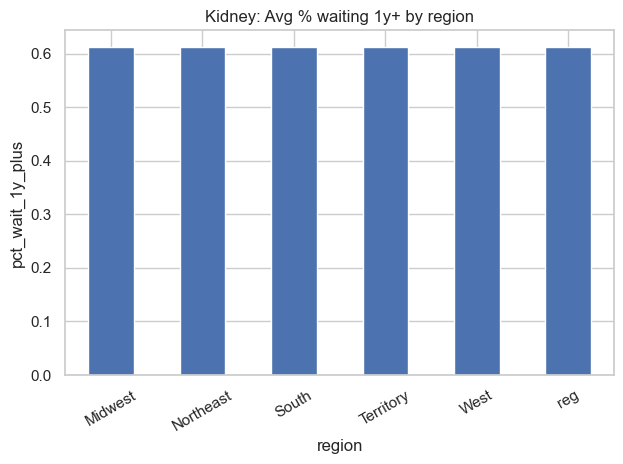

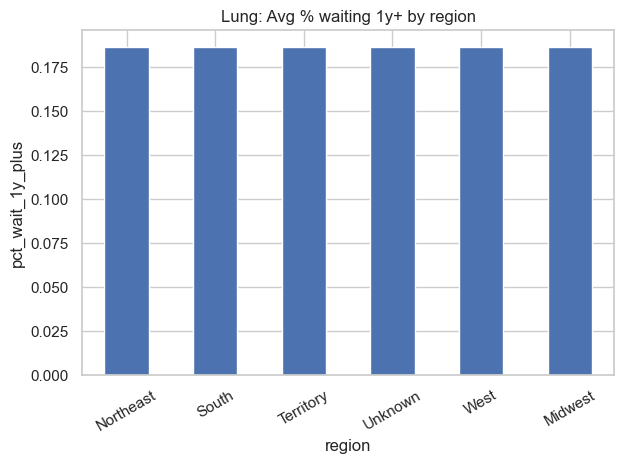

In [11]:
mean_wait_col = find_col(uno_wait, [r"est_mean_wait_days", r"mean_wait", r"wait_days"], required=False)
long_wait_col = find_col(uno_wait, [r"pct_wait_1y_plus", r"long_wait", r"wait_1y"], required=False)

if mean_wait_col:
    by_region = (uno_wait.groupby([organ_col, region_col], as_index=False)[mean_wait_col]
                 .median()
                 .sort_values([organ_col, mean_wait_col], ascending=[True, False]))
    for o in organs:
        tmp = by_region[by_region[organ_col] == o]
        plot_bar(tmp, x=region_col, y=mean_wait_col, title=f"{o}: Median estimated mean wait days by region", rotate=30)

if long_wait_col:
    by_region2 = (uno_wait.groupby([organ_col, region_col], as_index=False)[long_wait_col]
                  .mean()
                  .sort_values([organ_col, long_wait_col], ascending=[True, False]))
    for o in organs:
        tmp = by_region2[by_region2[organ_col] == o]
        plot_bar(tmp, x=region_col, y=long_wait_col, title=f"{o}: Avg % waiting 1y+ by region", rotate=30)

Insurance / SES relationship with access

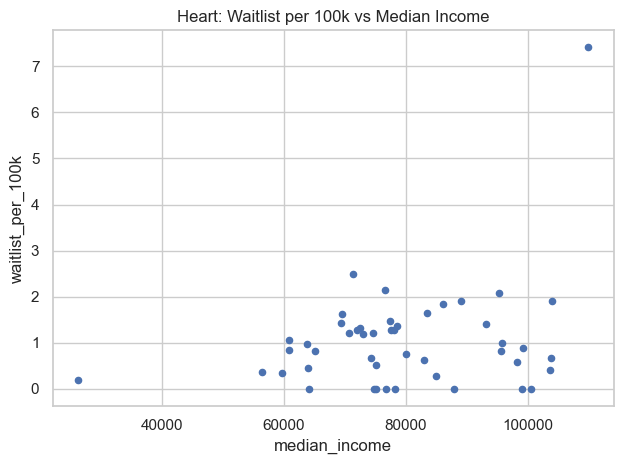

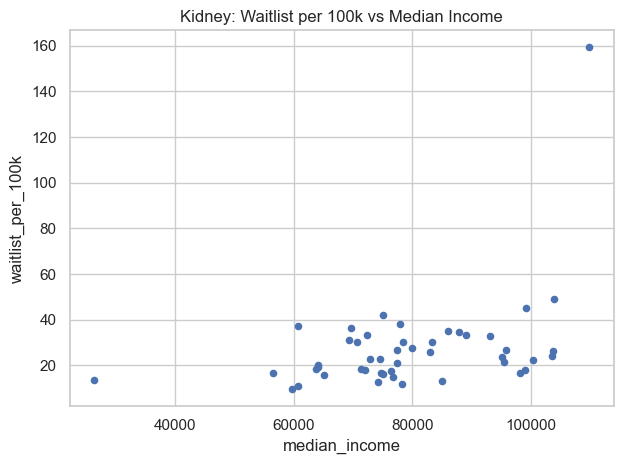

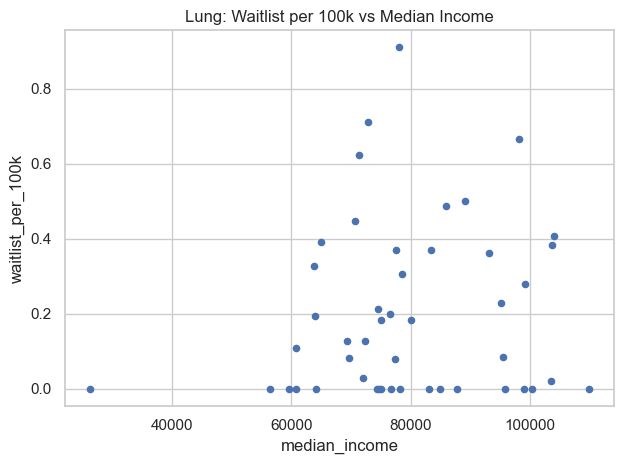

C:\Users\boame\AppData\Local\Temp\ipykernel_17580\4000326129.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_wait = (uno_wait_binned.groupby([organ_col, f"{income_col}_bin"], as_index=False)[mean_wait_col]


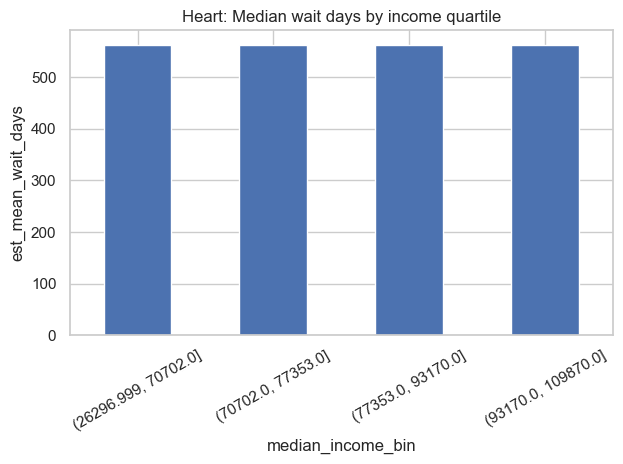

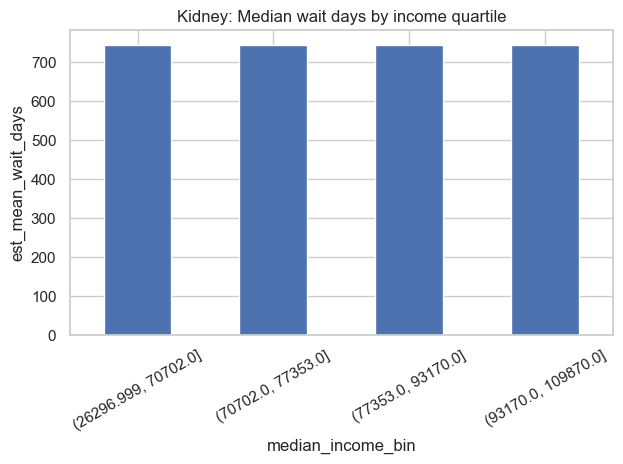

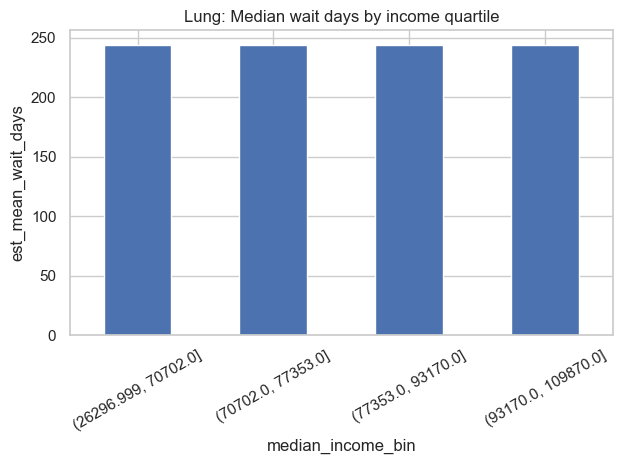

In [12]:
uninsured_col = find_col(uno_wait, [r"uninsured_share", r"uninsured"])
income_col = find_col(uno_wait, [r"median_income", r"income"])
poverty_col = find_col(uno_wait, [r"poverty_share", r"poverty"])

# Scatter: waitlist_per_100k vs median_income (per organ)
for o in organs:
    tmp = uno_wait[uno_wait[organ_col] == o].dropna(subset=[wait_rate_col, income_col])
    plot_scatter(tmp, x=income_col, y=wait_rate_col,
                 title=f"{o}: Waitlist per 100k vs Median Income")

# Bin income into quartiles (data-driven)
uno_wait_binned = add_quantile_bins(uno_wait, income_col, q=4)

if mean_wait_col:
    income_wait = (uno_wait_binned.groupby([organ_col, f"{income_col}_bin"], as_index=False)[mean_wait_col]
                   .median()
                   .sort_values([organ_col, mean_wait_col], ascending=[True, False]))
    for o in organs:
        tmp = income_wait[income_wait[organ_col] == o].copy()
        plot_bar(tmp, x=f"{income_col}_bin", y=mean_wait_col,
                 title=f"{o}: Median wait days by income quartile", rotate=30)

Outcome disparities: mortality while waiting

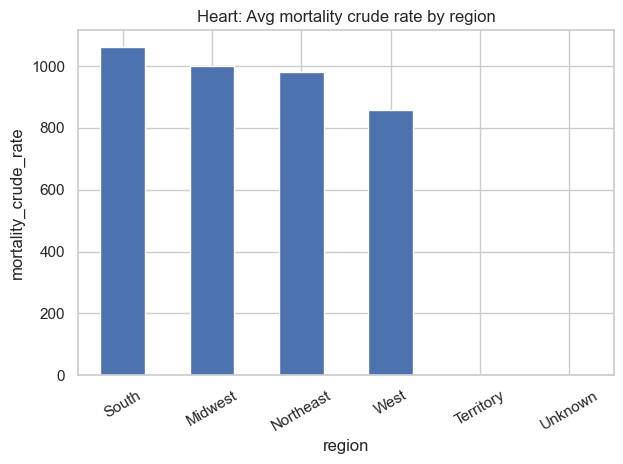

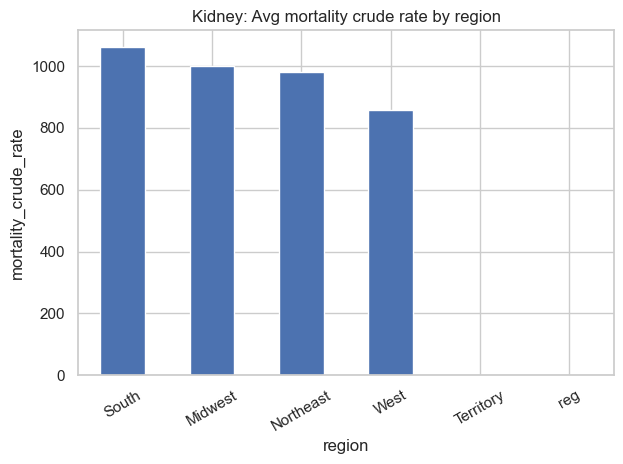

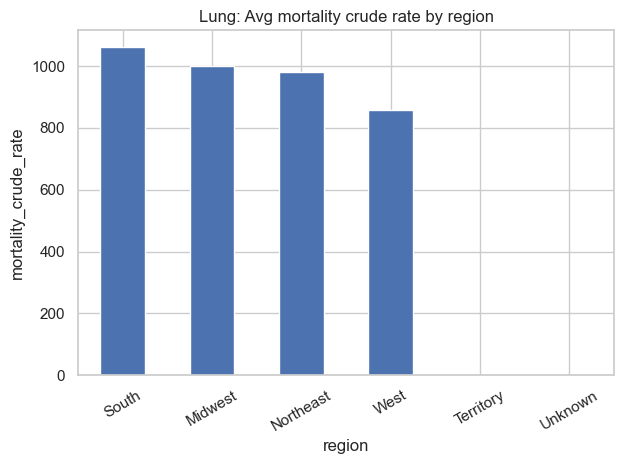

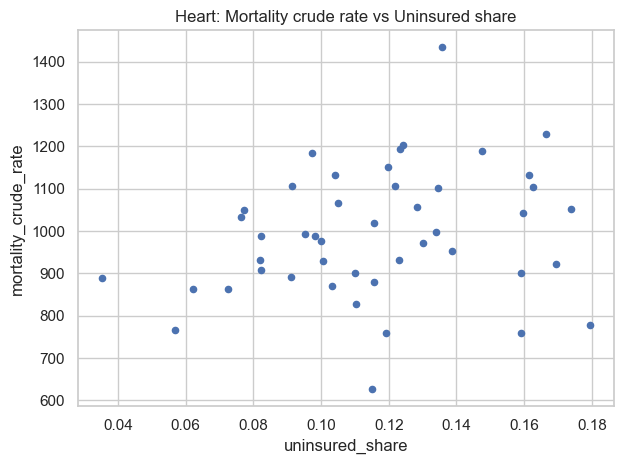

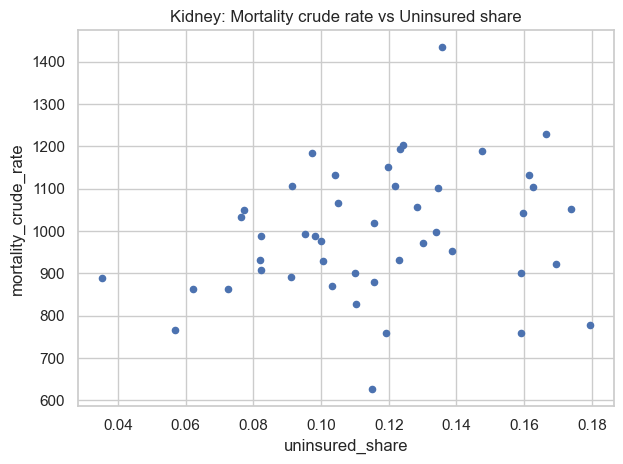

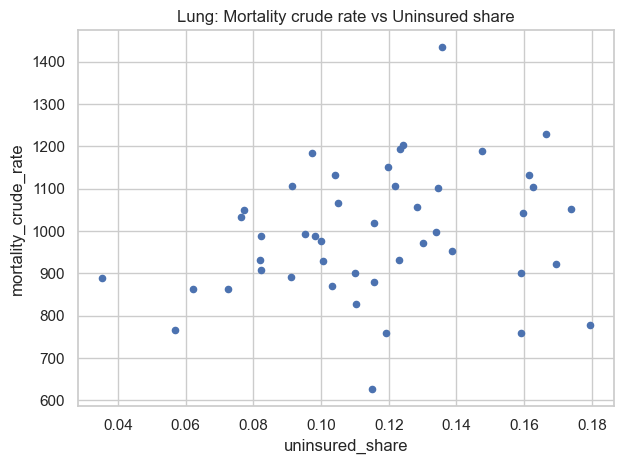

In [13]:
mort_col = find_col(uno_wait, [r"mortality_crude_rate", r"mortality"])
mort_by_region = (uno_wait.groupby([organ_col, region_col], as_index=False)[mort_col]
                  .mean()
                  .sort_values([organ_col, mort_col], ascending=[True, False]))

for o in organs:
    tmp = mort_by_region[mort_by_region[organ_col] == o]
    plot_bar(tmp, x=region_col, y=mort_col, title=f"{o}: Avg mortality crude rate by region", rotate=30)

# Relationship with uninsured share
for o in organs:
    tmp = uno_wait[uno_wait[organ_col] == o].dropna(subset=[mort_col, uninsured_col])
    plot_scatter(tmp, x=uninsured_col, y=mort_col, title=f"{o}: Mortality crude rate vs Uninsured share")

In [14]:
cand_buckets = pd.read_csv("Cand+reg_Organ_by_Waiting._Time.csv")
print("Loaded cand_buckets with shape:", cand_buckets.shape)
print("Columns:", cand_buckets.columns.tolist())

cb = cand_buckets.copy()
cb.columns = cb.columns.astype(str).str.strip()

organ_like = [c for c in cb.columns if re.search(r"organs?", c, re.I)]
type_like = [c for c in cb.columns if re.fullmatch(r"type", c, flags=re.I)]
cat_like  = [c for c in cb.columns if re.search(r"category", c, re.I)]

organ_c = organ_like[0]
type_c = type_like[0]
cat_c = cat_like[0]

# Forward-fill organ labels (no hard coding)
cb[organ_c] = cb[organ_c].ffill()

# Identify wait bucket columns programmatically (everything except identifiers)
id_cols = {organ_c, type_c, cat_c}
bucket_cols = [c for c in cb.columns if c not in id_cols]

# Convert bucket counts to numeric
for c in bucket_cols:
    cb[c] = clean_number_series(cb[c])

# Melt to long
cb_long = cb.melt(
    id_vars=[organ_c, type_c, cat_c],
    value_vars=bucket_cols,
    var_name="wait_bucket",
    value_name="count"
).dropna(subset=["count"])

# Filter to organs you care about using the data values (not manual categories)
target_organs = set(["Heart", "Kidney", "Lung"])
cb_long = cb_long[cb_long[organ_c].isin(target_organs)]

display(cb_long.head())

Loaded cand_buckets with shape: (153, 12)
Columns: ['All _Organs', 'Type', 'Category_type', 'All Time', '< 30 Days', '30 to < 90 Days', '90 Days to < 6 Months', '6 Months to < 1 Year', '1 Year to < 2 Years', '2 Years to < 3 Years', '3 Years to < 5 Years', '5 or More Years']


,All _Organs,Type,Category_type,wait_bucket,count
12,Kidney,All Races,Registrations,All Time,103106
13,Kidney,All Races,Candidates,All Time,94408
14,Kidney,White,Registrations,All Time,35702
15,Kidney,White,Candidates,All Time,32949
16,Kidney,Black,Registrations,All Time,30434


Race/ethnicity wait-bucket distribution charts

Region differences in waitlist rate

In [16]:
from scipy.stats import kruskal

# Example: test if waitlist_per_100k differs by region (within each organ)
for o in organs:
    tmp = uno_wait[uno_wait[organ_col] == o].dropna(subset=[wait_rate_col, region_col])
    groups = [g[wait_rate_col].values for _, g in tmp.groupby(region_col)]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        print(f"{o}: Kruskal-Wallis on {wait_rate_col} by region -> p={p:.4g}")

Heart: Kruskal-Wallis on waitlist_per_100k by region -> p=0.2299
Kidney: Kruskal-Wallis on waitlist_per_100k by region -> p=0.3451
Lung: Kruskal-Wallis on waitlist_per_100k by region -> p=0.4845


Using columns:
 organ_col     = organ
 region_col    = region
 state_col     = state
 mean_wait_col = est_mean_wait_days


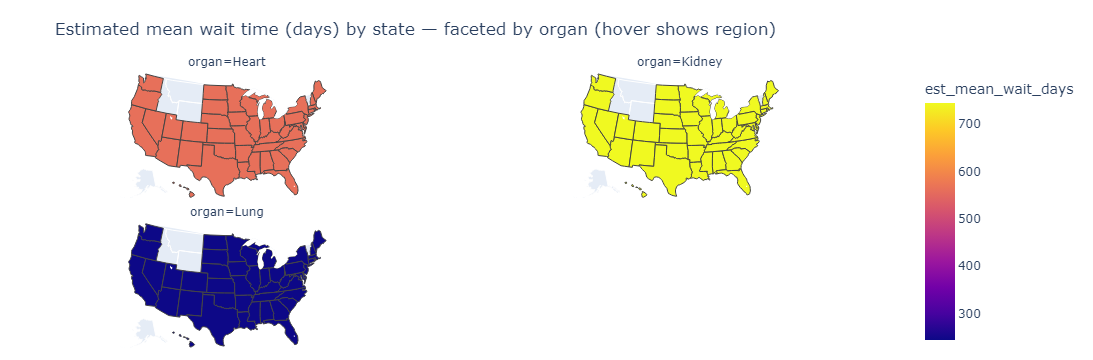

In [19]:
import pandas as pd
import numpy as np
import re
import plotly.express as px

# ---------- Helpers ----------
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
        .str.replace(r"[^a-z0-9_]", "", regex=True)
    )
    return df

def clean_number_series(s: pd.Series) -> pd.Series:
    if s.dtype != "O":
        return pd.to_numeric(s, errors="coerce")
    out = (
        s.astype(str)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan})
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
    )
    return pd.to_numeric(out, errors="coerce")

def find_col(df: pd.DataFrame, patterns: list[str], required=True) -> str | None:
    cols = list(df.columns)
    for pat in patterns:
        rx = re.compile(pat, flags=re.I)
        matches = [c for c in cols if rx.search(c)]
        if matches:
            return matches[0]
    if required:
        raise KeyError(f"Could not find a column matching patterns: {patterns}\nAvailable: {cols}")
    return None

# ---------- Load ----------
uno_wait = standardize_columns(pd.read_csv("uno_waitlist.csv"))
census   = standardize_columns(pd.read_csv("census_cleaned.csv"))

# ---------- Find key columns ----------
organ_col  = find_col(uno_wait, [r"^organ$", r"organ"])
region_col = find_col(uno_wait, [r"^region$", r"region"])
state_col  = find_col(uno_wait, [r"^state$", r"state"])

mean_wait_col = find_col(
    uno_wait,
    [r"^est_mean_wait_days$", r"est.*mean.*wait", r"mean.*wait.*days", r"wait.*days"]
)

# Clean fields
uno_wait[state_col] = uno_wait[state_col].astype(str).str.strip()
uno_wait[mean_wait_col] = clean_number_series(uno_wait[mean_wait_col])

print("Using columns:")
print(" organ_col     =", organ_col)
print(" region_col    =", region_col)
print(" state_col     =", state_col)
print(" mean_wait_col =", mean_wait_col)

# ---------- Ensure 2-letter state abbreviations (no hard-coding) ----------
state_vals = uno_wait[state_col].dropna().astype(str).str.strip()
abbr_like = (state_vals.str.len() == 2).mean()

if abbr_like >= 0.9:
    uno_wait["state_abbr"] = uno_wait[state_col].str.upper()
else:
    # map state names -> abbreviations using census_cleaned
    census_name_col = find_col(census, [r"^name$", r"state_name", r"statename"])
    census_abbr_col = find_col(census, [r"abbr", r"postal", r"stusps", r"state_code", r"^state$"])

    name_to_abbr = (
        census[[census_name_col, census_abbr_col]]
        .dropna()
        .assign(
            name=lambda d: d[census_name_col].astype(str).str.strip().str.lower(),
            abbr=lambda d: d[census_abbr_col].astype(str).str.strip().str.upper()
        )
        .drop_duplicates(subset=["name"])
        .set_index("name")["abbr"]
        .to_dict()
    )

    uno_wait["state_abbr"] = uno_wait[state_col].astype(str).str.strip().str.lower().map(name_to_abbr)

# Keep rows we can map
m = uno_wait.dropna(subset=["state_abbr", mean_wait_col, organ_col, region_col]).copy()

# Aggregate to one value per (state, region, organ)
map_df = (
    m.groupby(["state_abbr", region_col, organ_col], as_index=False)[mean_wait_col]
     .mean()
)

# ---------- Map: wait time by state, faceted by organ ----------
fig = px.choropleth(
    map_df,
    locations="state_abbr",
    locationmode="USA-states",
    scope="usa",
    color=mean_wait_col,
    hover_name="state_abbr",
    hover_data={region_col: True, organ_col: True, mean_wait_col: ':.0f'},
    facet_col=organ_col,
    facet_col_wrap=2
)

fig.update_layout(
    title="Estimated mean wait time (days) by state — faceted by organ (hover shows region)",
    margin=dict(l=10, r=10, t=70, b=10)
)

fig.show()